<a href="https://colab.research.google.com/github/Roshni-AngelAlex/DEEP-LEARNING/blob/main/24BAD101_DL_Lab_EX%202_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DEEP LEARNING (24ADI006)

# LAB EXPT 2: Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning

NAME: ROSHNI ANGEL A

ROLL NO: 24BAD101

DEPARTMENT: AI/DS


In [1]:
# Imports (all pre-installed in Colab)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


## Task A: Visualization of Activation Functions

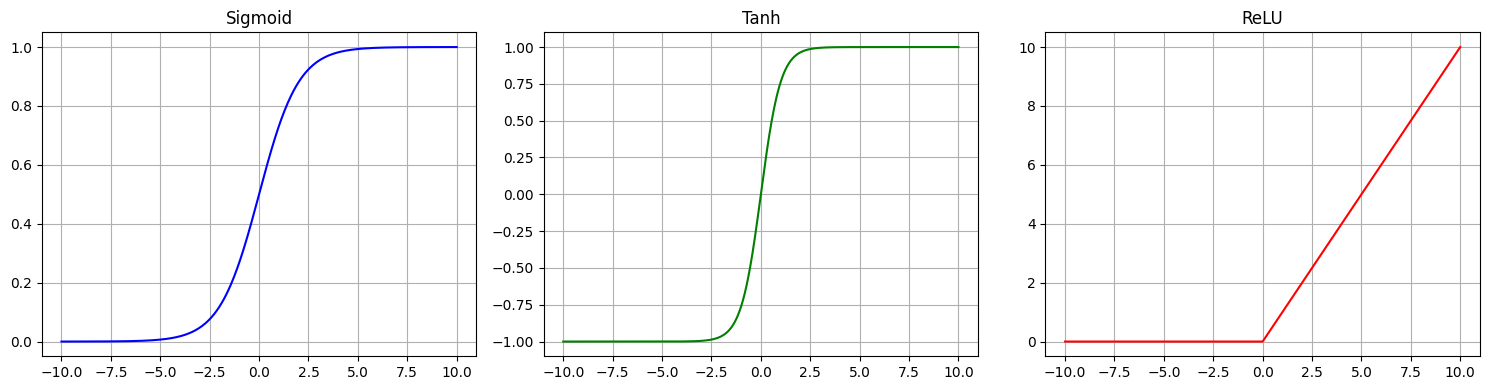

In [2]:
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)

x = np.linspace(-10, 10, 500)
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid(x), color='blue'); plt.title('Sigmoid'); plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, tanh(x), color='green'); plt.title('Tanh'); plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, relu(x), color='red'); plt.title('ReLU'); plt.grid(True)

plt.tight_layout()
plt.savefig('task_a_activation_functions.png')
plt.show()

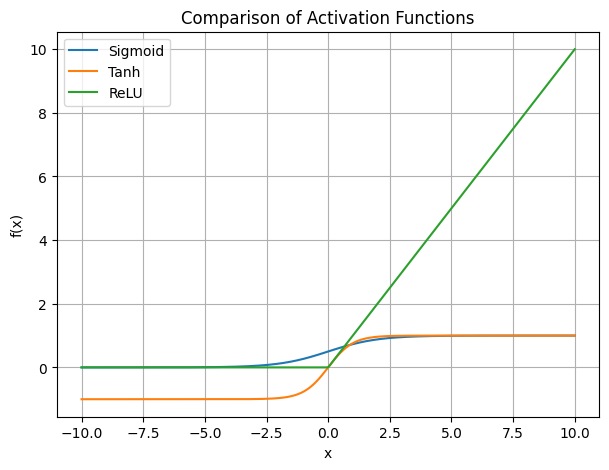

In [4]:
# Combined comparison plot
plt.figure(figsize=(7, 5))
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.plot(x, tanh(x), label='Tanh')
plt.plot(x, relu(x), label='ReLU')
plt.title('Comparison of Activation Functions')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(); plt.grid(True)
plt.savefig('task_a_comparison.png')
plt.show()

## Task B: Performance Comparison of Activation Functions (MNIST)

In [17]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28*28).astype('float32') / 255.0

def build_model(activation_fn):
    model = keras.Sequential([
        layers.Dense(128, activation=activation_fn, input_shape=(784,)),
        layers.Dense(64, activation=activation_fn),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

activations = ['sigmoid', 'tanh', 'relu']
history_dict = {}

for act in activations:
    print(f'Training model with {act} activation...')
    model = build_model(act)
    history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=0)
    history_dict[act] = history.history
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'{act.upper()} -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}')

    # Store the trained model in a global variable
    if act == 'sigmoid':
        sigmoid_model = model
    elif act == 'tanh':
        tanh_model = model
    elif act == 'relu':
        relu_model = model


Training model with sigmoid activation...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SIGMOID -> Test Accuracy: 0.9717, Test Loss: 0.0950
Training model with tanh activation...
TANH -> Test Accuracy: 0.9748, Test Loss: 0.0794
Training model with relu activation...
RELU -> Test Accuracy: 0.9746, Test Loss: 0.0826


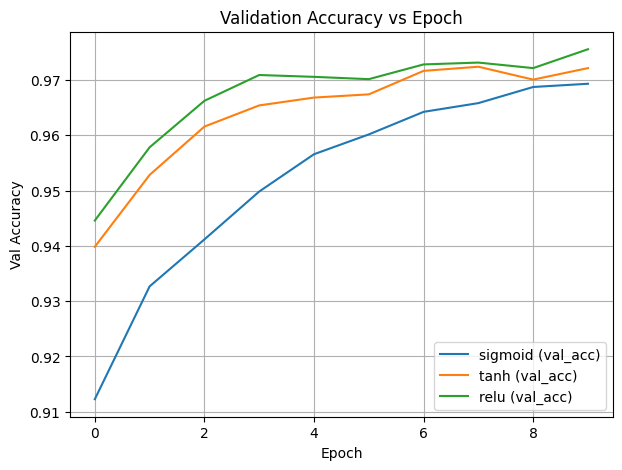

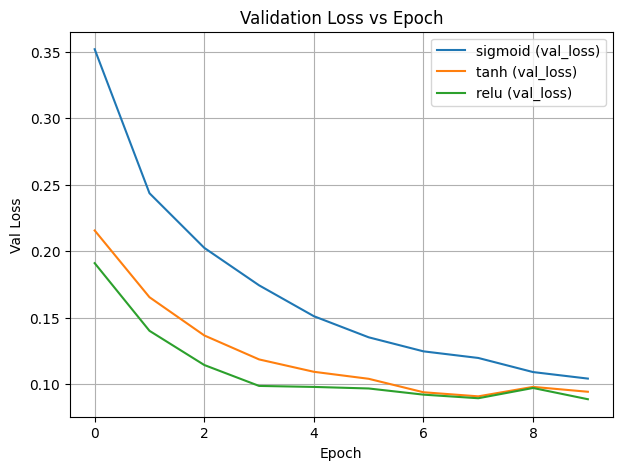

In [6]:
plt.figure(figsize=(7,5))
for act in activations:
    plt.plot(history_dict[act]['val_accuracy'], label=f'{act} (val_acc)')
plt.title('Validation Accuracy vs Epoch'); plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend(); plt.grid(True)
plt.savefig('task_b_val_accuracy.png')
plt.show()

plt.figure(figsize=(7,5))
for act in activations:
    plt.plot(history_dict[act]['val_loss'], label=f'{act} (val_loss)')
plt.title('Validation Loss vs Epoch'); plt.xlabel('Epoch'); plt.ylabel('Val Loss')
plt.legend(); plt.grid(True)
plt.savefig('task_b_val_loss.png')
plt.show()

## Task C: Comparison of Optimization Algorithms

In [18]:
def build_fixed_model():
    return keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

optimizer_configs = {
    'SGD': optimizers.SGD(learning_rate=0.01),
    'Momentum': optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': optimizers.RMSprop(learning_rate=0.001),
    'Adam': optimizers.Adam(learning_rate=0.001)
}

optimizer_history = {}
for name, opt in optimizer_configs.items():
    print(f'Training model with {name} optimizer...')
    model = build_fixed_model()
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=0)
    optimizer_history[name] = history.history
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'{name} -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}')

    # Store the Adam model in a global variable
    if name == 'Adam':
        adam_model = model


Training model with SGD optimizer...
SGD -> Test Accuracy: 0.9292, Test Loss: 0.2470
Training model with Momentum optimizer...
Momentum -> Test Accuracy: 0.9732, Test Loss: 0.0911
Training model with RMSProp optimizer...
RMSProp -> Test Accuracy: 0.9773, Test Loss: 0.0788
Training model with Adam optimizer...
Adam -> Test Accuracy: 0.9763, Test Loss: 0.0828


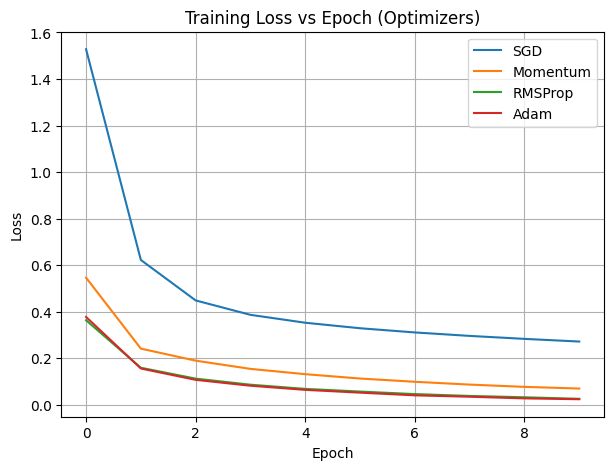

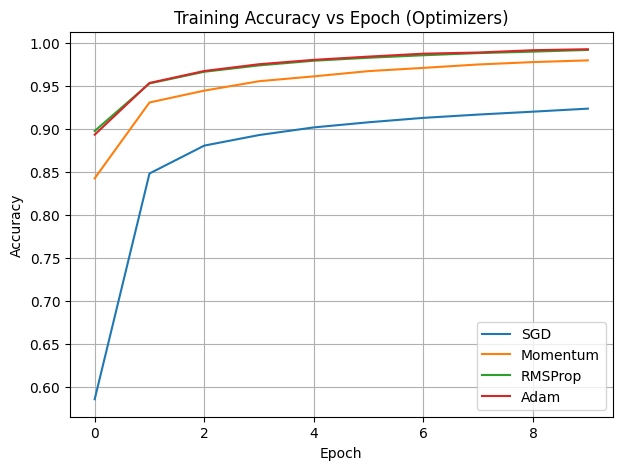

In [8]:
plt.figure(figsize=(7,5))
for name in optimizer_configs:
    plt.plot(optimizer_history[name]['loss'], label=name)
plt.title('Training Loss vs Epoch (Optimizers)'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)
plt.savefig('task_c_loss_vs_epoch.png')
plt.show()

plt.figure(figsize=(7,5))
for name in optimizer_configs:
    plt.plot(optimizer_history[name]['accuracy'], label=name)
plt.title('Training Accuracy vs Epoch (Optimizers)'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)
plt.savefig('task_c_accuracy_vs_epoch.png')
plt.show()

## Task D: Experiment Management (Google Drive + GitHub)

In [14]:
# TASK D: GOOGLE DRIVE
# STUDENT ROLL NO: 24BAD101


from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [15]:
# CREATE EXPERIMENT FOLDER


import os

experiment_path = "/content/drive/MyDrive/EXPT_2_Deep_Learning"

os.makedirs(experiment_path, exist_ok=True)

print("Experiment folder:", experiment_path)

Experiment folder: /content/drive/MyDrive/EXPT_2_Deep_Learning


In [19]:
# SAVE TRAINED MODELS

sigmoid_model.save(
    experiment_path + "/sigmoid_model.keras"
)

tanh_model.save(
    experiment_path + "/tanh_model.keras"
)

relu_model.save(
    experiment_path + "/relu_model.keras"
)

adam_model.save(
    experiment_path + "/adam_model.keras"
)

print("Models saved successfully in Google Drive.")

Models saved successfully in Google Drive.


In [21]:
# SAVE RESULTS
import pandas as pd

# Create results_activation DataFrame
activation_data = []
for act in activations:
    final_val_acc = history_dict[act]['val_accuracy'][-1]
    final_val_loss = history_dict[act]['val_loss'][-1]
    activation_data.append({
        'Activation Function': act,
        'Final Validation Accuracy': final_val_acc,
        'Final Validation Loss': final_val_loss
    })
results_activation = pd.DataFrame(activation_data)

# Create optimizer_results DataFrame
optimizer_data = []
for name in optimizer_configs.keys():
    final_val_acc = optimizer_history[name]['val_accuracy'][-1]
    final_val_loss = optimizer_history[name]['val_loss'][-1]
    optimizer_data.append({
        'Optimizer': name,
        'Final Validation Accuracy': final_val_acc,
        'Final Validation Loss': final_val_loss
    })
optimizer_results = pd.DataFrame(optimizer_data)

activation_file = experiment_path + "/activation_results.csv"
optimizer_file = experiment_path + "/optimizer_results.csv"

results_activation.to_csv(
    activation_file,
    index=False
)

optimizer_results.to_csv(
    optimizer_file,
    index=False
)

print("Result files saved successfully.")

Result files saved successfully.


In [22]:
# EXPERIMENT SUMMARY

summary = """
EXPT NO: 2
Title: Comparative Study of Activation Functions and Optimization Algorithms

Activation Functions:
1. Sigmoid
2. Tanh
3. ReLU

Optimization Algorithms:
1. SGD
2. Momentum
3. RMSProp
4. Adam

Dataset:
MNIST Handwritten Digit Dataset

ANN Architecture:
Flatten -> Dense(128) -> Dense(64) -> Dense(10)

Results are stored in Google Drive.
"""

summary_path = experiment_path + "/experiment_summary.txt"

with open(summary_path, "w") as file:
    file.write(summary)

print("Experiment summary saved.")

Experiment summary saved.


In [23]:
# CHECK GOOGLE DRIVE FILES

import os

for file in os.listdir(experiment_path):
    print(file)

sigmoid_model.keras
tanh_model.keras
relu_model.keras
adam_model.keras
activation_results.csv
optimizer_results.csv
experiment_summary.txt
